<a href="https://colab.research.google.com/github/ElFuegoX/100DaysofML/blob/main/Notebooks/008_Bayesian_Linear_Regression/algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importation des packages

In [1]:

# Importer les modules nécessaires
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## Chargement des données

Les données concernent  des informations qui permettent de décider de la qualité d'un vin.

In [2]:
whine_quality = pd.read_csv('WineQT.csv', sep=',')

## Exploration des données

In [3]:
whine_quality.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

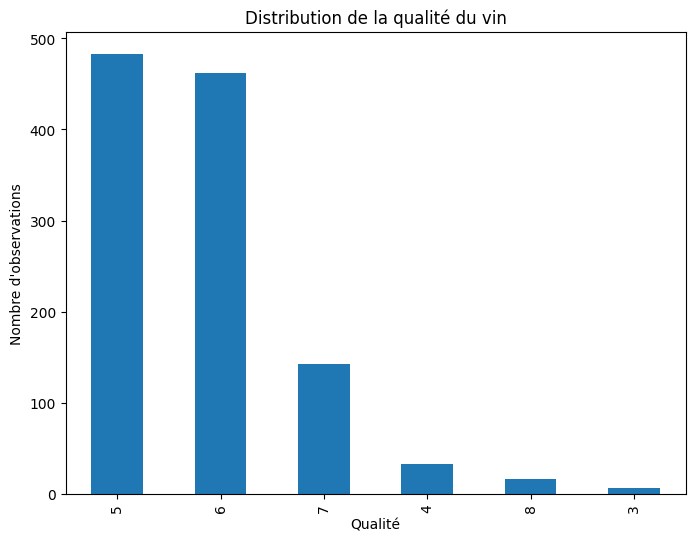

In [4]:
# Distribution de la variable cible 'quality'
plt.figure(figsize=(8, 6))
whine_quality['quality'].value_counts().plot(kind='bar')
plt.title('Distribution de la qualité du vin')
plt.xlabel('Qualité')
plt.ylabel('Nombre d\'observations')
plt.show()

In [5]:
# Créer une nouvelle version de la base de données sans les variables "quality" et "id"
whine_quality_new = whine_quality.drop(columns=['quality', 'Id'], axis=1)
whine_quality_new.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


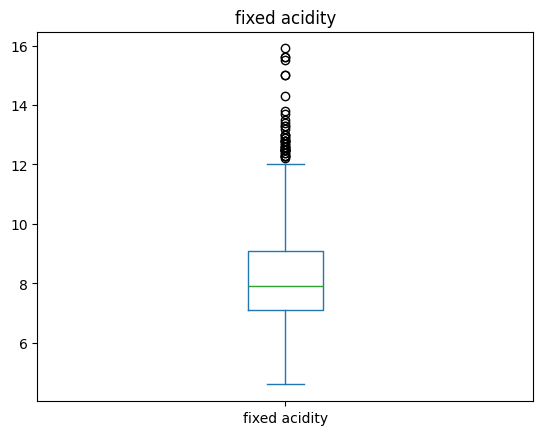

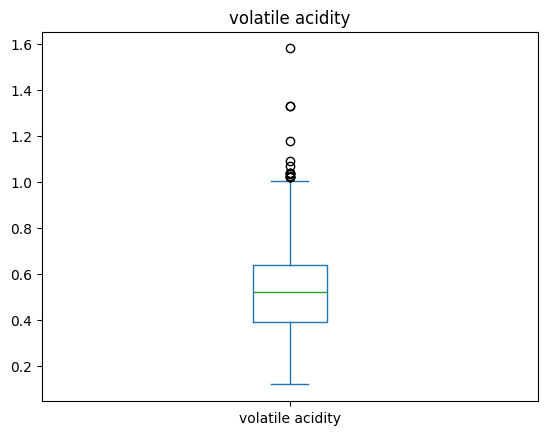

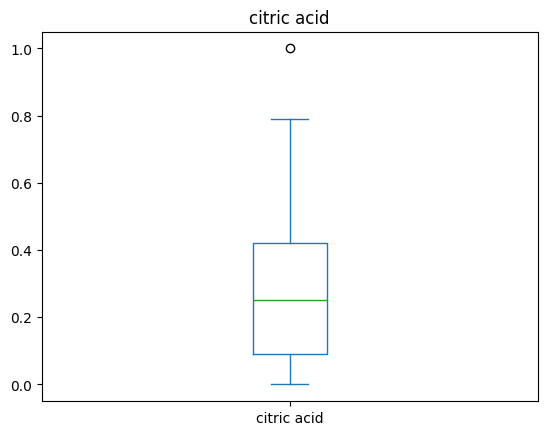

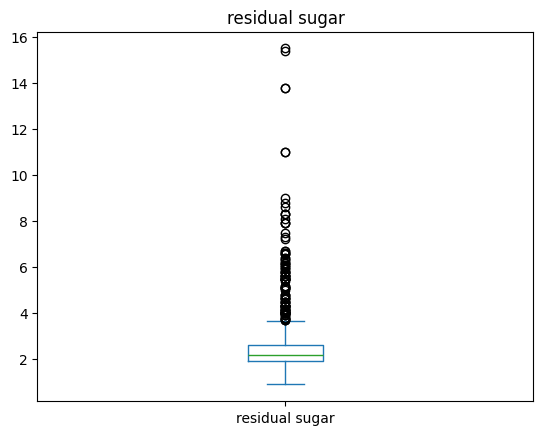

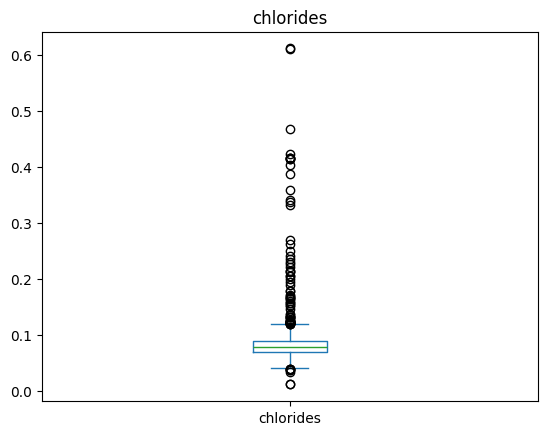

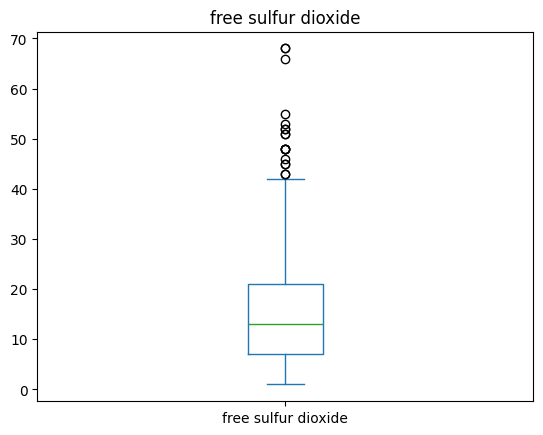

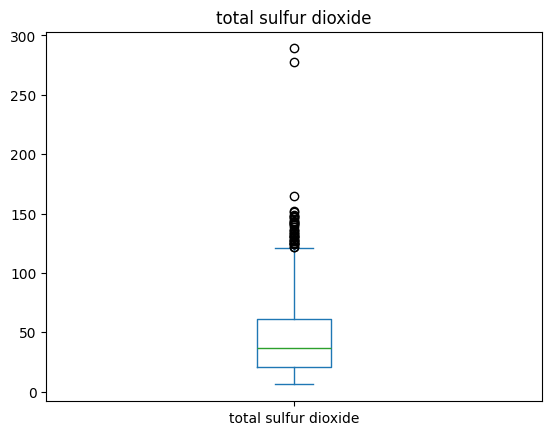

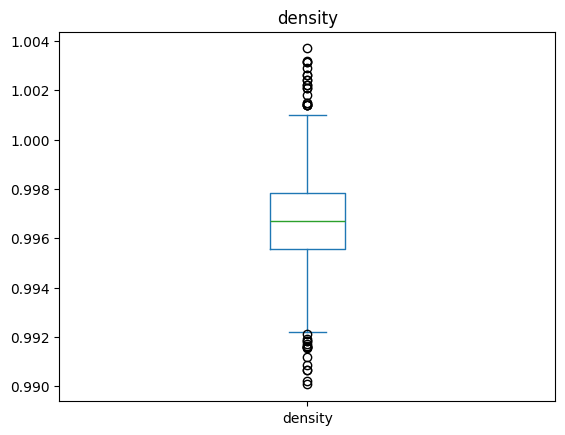

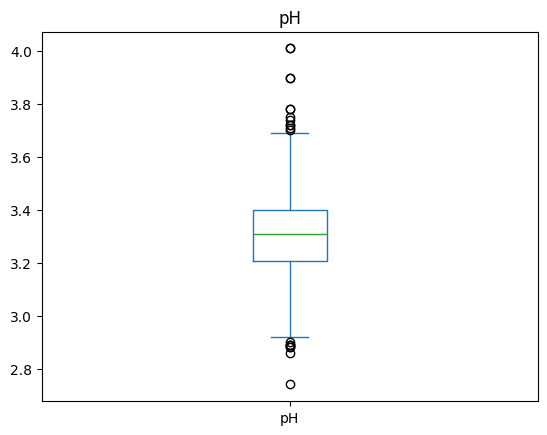

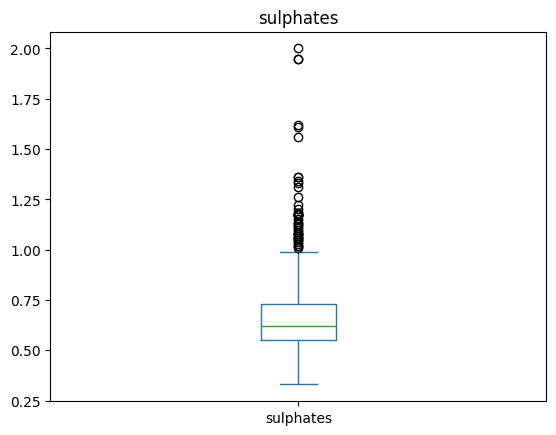

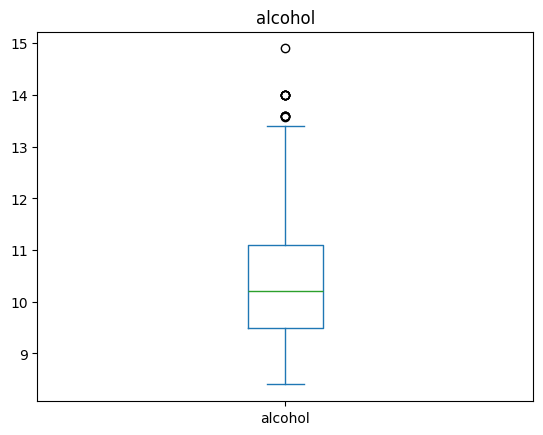

In [6]:
# Générer un box plot pour chaque variable
for var in whine_quality_new.columns:
    whine_quality_new[var].plot(kind='box')
    plt.title(var)
    plt.show()

## Analyse bivariée et création des classes

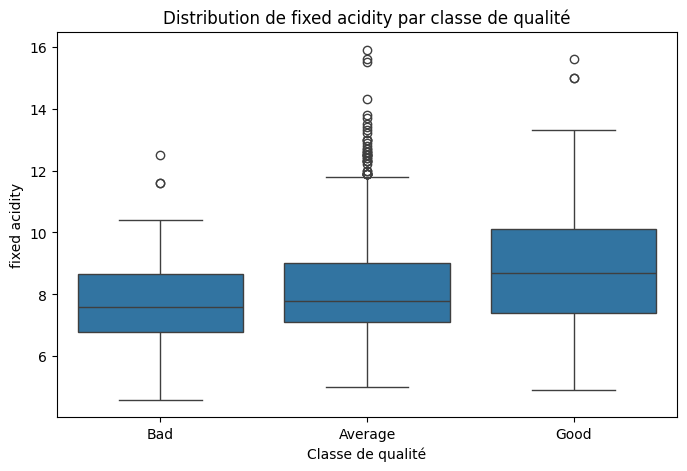

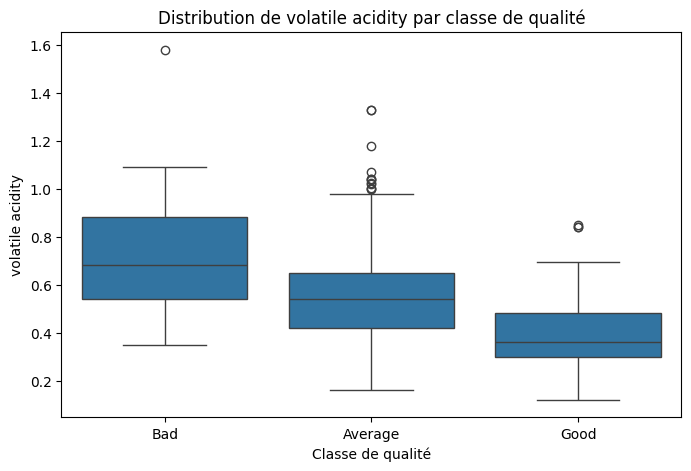

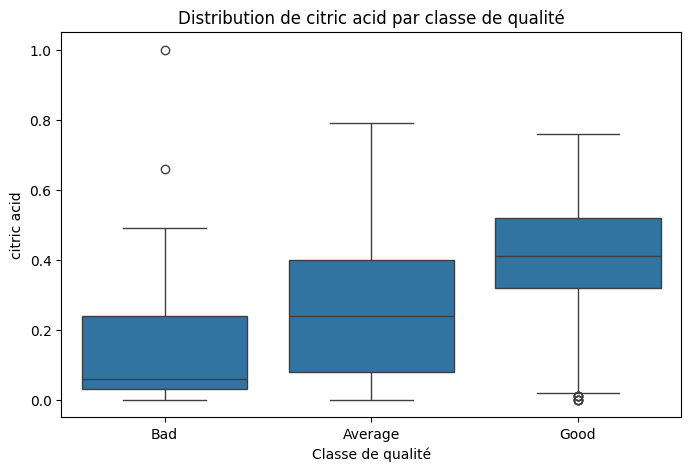

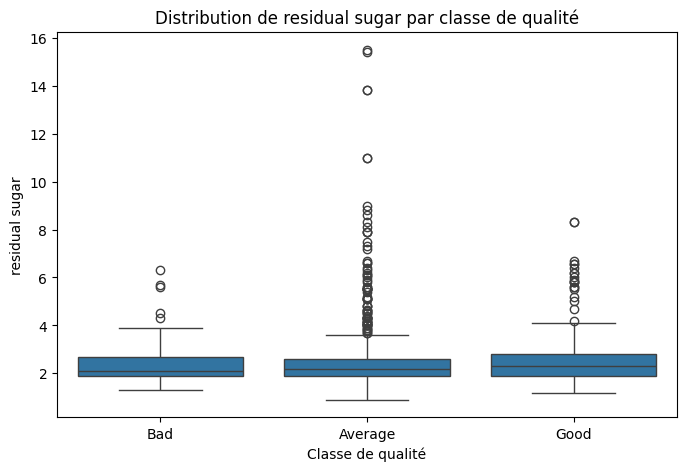

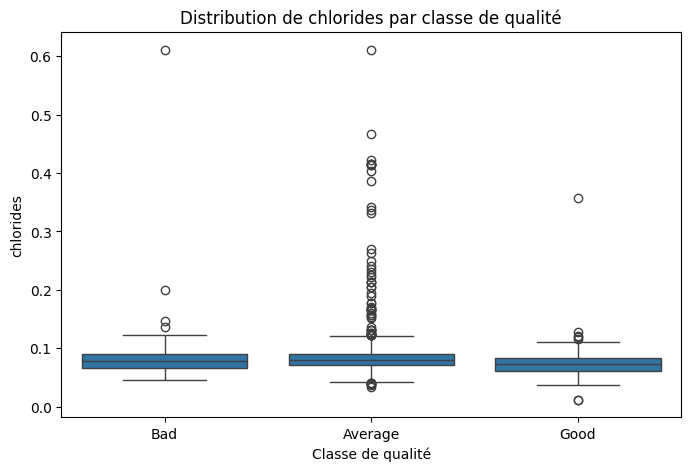

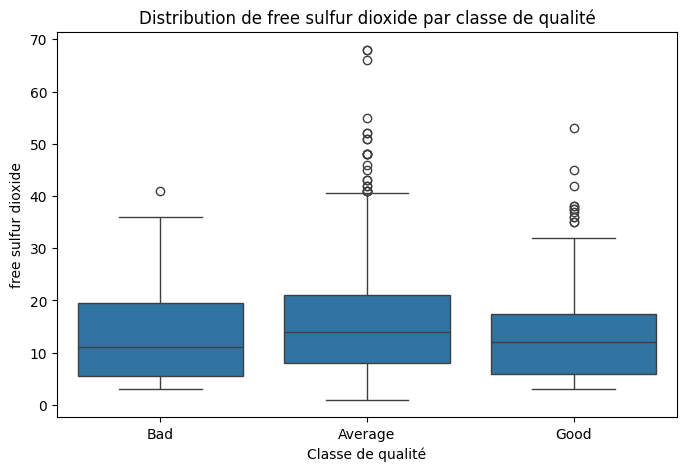

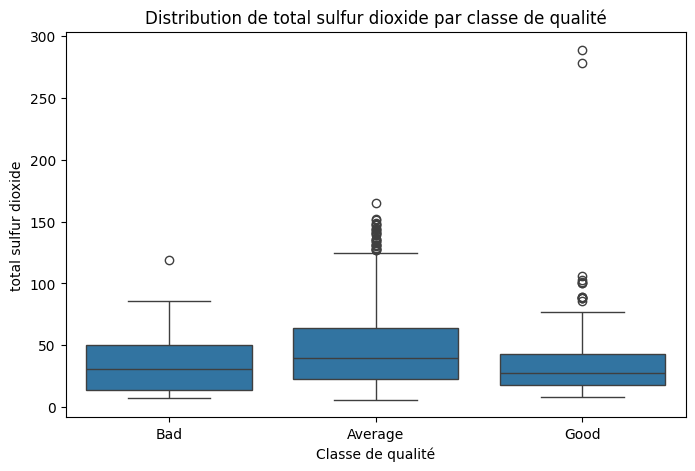

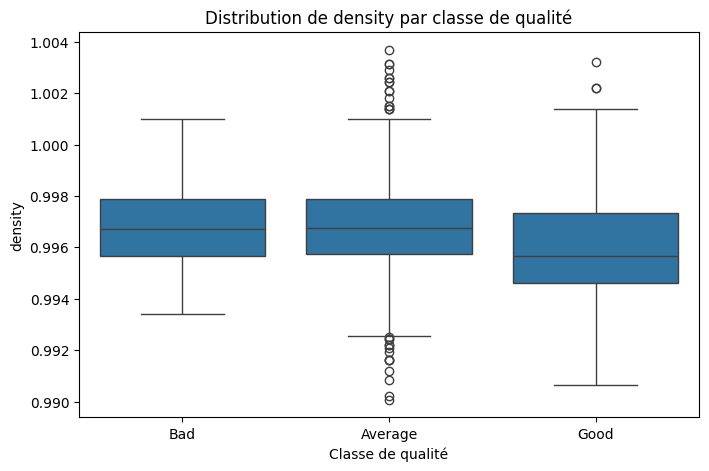

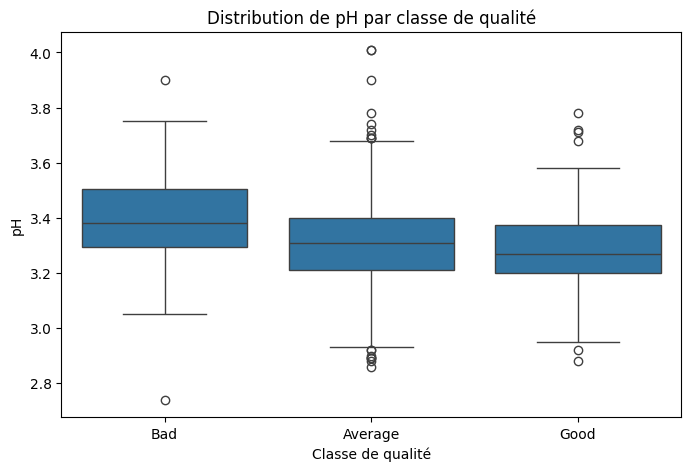

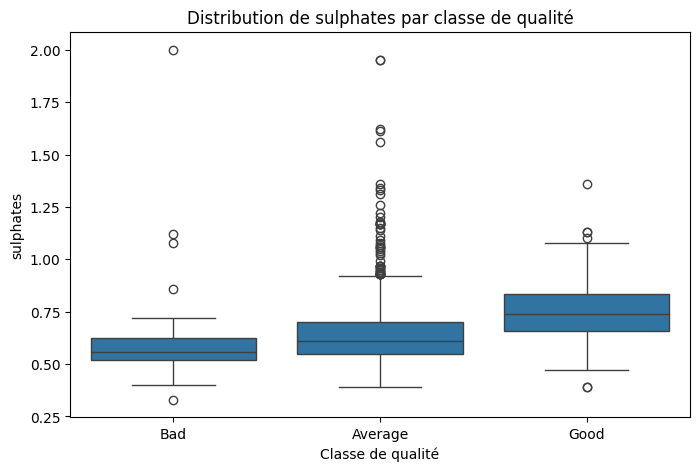

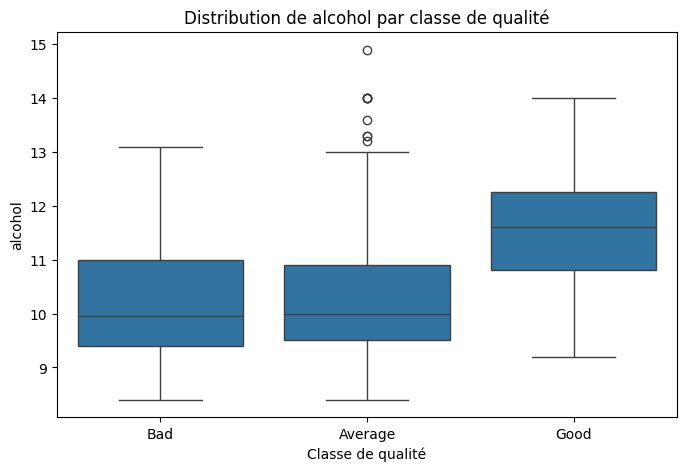

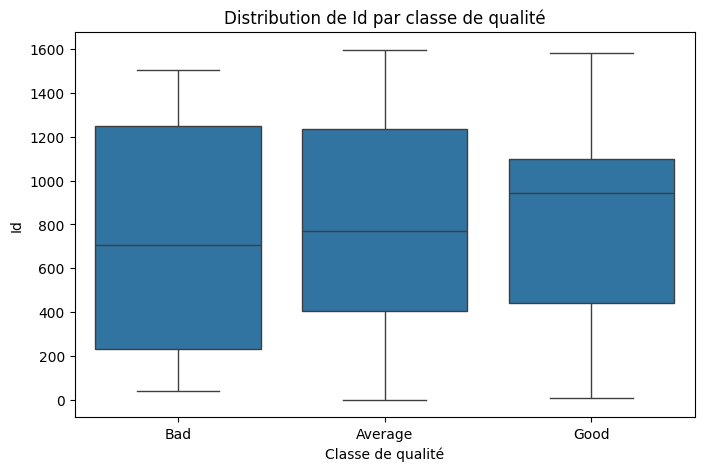

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Créer trois classes pour la variable quality: Bad (3,4), Average (5,6) et Good (7,8)
whine_quality['quality'] = whine_quality['quality'].apply(
    lambda x: 'Bad' if (x <= 4) else ('Average' if (x <= 6) else 'Good')
)

# Définir l'ordre des catégories pour un affichage logique
quality_order = ['Bad', 'Average', 'Good']

# Générer un box plot pour chaque variable en fonction de la classe de qualité
for var in whine_quality.columns:
    if var != 'quality':
        plt.figure(figsize=(8, 5))
        sns.boxplot(x='quality', y=var, data=whine_quality, order=quality_order)
        plt.title(f'Distribution de {var} par classe de qualité')
        plt.xlabel('Classe de qualité')
        plt.ylabel(var)
        plt.show()

In [8]:
# Créer une colonne supplémentaire pour la classe de qualité ( Bad=0, Average=1, Good=2)
quality_mapping = {'Bad': 0, 'Average': 1, 'Good': 2}
whine_quality_new['quality_class'] = whine_quality['quality'].map(quality_mapping)

whine_quality_new.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality_class
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,1


In [9]:
import scipy.stats as stats
# Initialiser les listes pour stocker les résultats
var_names = []
kw_stats = []
p_values = []

# Parcourir toutes les variables numériques
for var in whine_quality_new.columns:
    # Calculer les groupes de valeurs
    groups = [whine_quality_new[whine_quality_new['quality_class'] == 0][var], whine_quality_new[whine_quality_new['quality_class'] == 1][var], whine_quality_new[whine_quality_new['quality_class'] == 2][var]]
    # Appliquer le test de Kruskal-Wallis
    kw_stat, p = stats.kruskal(*groups)
    # Ajouter les résultats aux listes correspondantes
    var_names.append(var)
    kw_stats.append(kw_stat)
    p_values.append(p)

# Créer un DataFrame avec les résultats
results_df = pd.DataFrame({
    'Variable': var_names,
    'Kruskal-Wallis': kw_stats,
    'P-valeur': p_values
})

# Trier le DataFrame par ordre croissant de p-valeur
results_df.sort_values(by='P-valeur', inplace=True)

# Afficher le tableau des résultats
print(results_df)

                Variable  Kruskal-Wallis       P-valeur
11         quality_class     1142.000000  1.041959e-248
10               alcohol      167.685785   3.868072e-37
1       volatile acidity      141.584725   1.799980e-31
9              sulphates      102.548646   5.393173e-23
2            citric acid       77.654054   1.372892e-17
4              chlorides       36.374933   1.262652e-08
6   total sulfur dioxide       28.625165   6.083091e-07
7                density       26.881944   1.454320e-06
0          fixed acidity       18.506637   9.579322e-05
8                     pH       15.059469   5.368808e-04
5    free sulfur dioxide        7.355497   2.527983e-02
3         residual sugar        4.162464   1.247764e-01


## Modélisation

In [10]:
import statsmodels.api as sm
# Sélectionner les variables explicatives et la variable d'intérêt
X = whine_quality_new[['fixed acidity', 'volatile acidity', 'citric acid',  'chlorides',  'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']]
y = whine_quality_new['quality_class']

In [11]:
from sklearn.preprocessing import StandardScaler
# Ajouter une constante pour l'interception
X = sm.add_constant(X)

# Diviser les données en ensembles d'apprentissage et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [12]:

# Standardiser les données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# Créer le modèle de régression logistique
model = LogisticRegression(
    solver='lbfgs',
    max_iter=1250,
    class_weight=None,
    random_state=42
)

In [14]:
# Ajuster le modèle aux données d'apprentissage
result = model.fit(X_train_scaled, y_train)


In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Prédictions pour Train
y_train_pred = result.predict(X_train_scaled)

# Prédictions pour Test
y_test_pred = result.predict(X_test_scaled)


print("CLASSIFICATION REPORT - ENSEMBLE D'ENTRAÎNEMENT")
print(classification_report(y_train, y_train_pred,
                          target_names=['Bad', 'Average', 'Good']))

print("CLASSIFICATION REPORT - ENSEMBLE DE TEST \n")

print(classification_report(y_test, y_test_pred,
                          target_names=['Bad', 'Average', 'Good']))



CLASSIFICATION REPORT - ENSEMBLE D'ENTRAÎNEMENT
              precision    recall  f1-score   support

         Bad       0.50      0.03      0.06        32
     Average       0.86      0.96      0.90       703
        Good       0.58      0.32      0.41       122

    accuracy                           0.83       857
   macro avg       0.65      0.44      0.46       857
weighted avg       0.80      0.83      0.80       857

CLASSIFICATION REPORT - ENSEMBLE DE TEST 

              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00         7
     Average       0.89      0.95      0.92       242
        Good       0.62      0.43      0.51        37

    accuracy                           0.86       286
   macro avg       0.50      0.46      0.48       286
weighted avg       0.83      0.86      0.85       286



## Régression Linéaire Bayésienne

In [16]:
import pandas as pd
import bambi as bmb
import arviz as az

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [17]:

print("Valeurs uniques de quality_class:")
print(whine_quality['quality'].unique())

Valeurs uniques de quality_class:
['Average' 'Good' 'Bad']


In [18]:
# Renommer les colonnes pour qu'elles soient compatibles avec Bambi
whine_quality = whine_quality.rename(columns={
    'fixed acidity': 'fixed_acidity',
    'volatile acidity': 'volatile_acidity',
    'citric acid': 'citric_acid',
    'chlorides': 'chlorides',
    'total sulfur dioxide': 'total_sulfur_dioxide',
    'density': 'density',
    'pH': 'pH',
    'sulphates': 'sulphates',
    'alcohol': 'alcohol'
})

from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(whine_quality, test_size=0.2, random_state=42)
labels = sorted(whine_quality['quality'].unique())

# Entraîner le modèle bayésien sur le train_df
model_bayes = bmb.Model('quality ~ fixed_acidity + volatile_acidity + citric_acid + chlorides + total_sulfur_dioxide + density + pH + sulphates + alcohol',
                        data=train_df,
                        family='categorical')
result = model_bayes.fit(draws=1000, tune=1000, chains=4, target_accept=0.8, random_seed=42)

# Générer les prédictions
model_bayes.predict(result, data=train_df)
y_train_pred = result.posterior_predictive['quality'].mean(dim=['chain', 'draw']).values.argmax(axis=1)

model_bayes.predict(result, data=test_df)
y_test_pred = result.posterior_predictive['quality'].mean(dim=['chain', 'draw']).values.argmax(axis=1)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, fixed_acidity, volatile_acidity, citric_acid, chlorides, total_sulfur_dioxide, density, pH, sulphates, alcohol]


C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\
Python311\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

ValueError: Not enough samples to build a trace.

In [ ]:
# Train
y_train_pred_labels = [labels[i] for i in y_train_pred]
y_train_true = train_df["quality"].values

# Test
y_test_pred_labels = [labels[i] for i in y_test_pred]
y_test_true = test_df["quality"].values


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# TRAIN
acc_train = accuracy_score(y_train_true, y_train_pred_labels)
f1_train  = f1_score(y_train_true, y_train_pred_labels, average="weighted")
cm_train  = confusion_matrix(y_train_true, y_train_pred_labels, labels=labels)

# TEST
acc_test = accuracy_score(y_test_true, y_test_pred_labels)
f1_test  = f1_score(y_test_true, y_test_pred_labels, average="weighted")
cm_test  = confusion_matrix(y_test_true, y_test_pred_labels, labels=labels)

print("=== TRAIN ===")
print("Accuracy:", acc_train)
print("F1-score:", f1_train)
print("Confusion Matrix:\n", cm_train)

print("\n=== TEST ===")
print("Accuracy:", acc_test)
print("F1-score:", f1_test)
print("Confusion Matrix:\n", cm_test)
